# Qubit coupled to Two-level system (TLS) with white noise

### Author: Daniel Gonçalves Benvenutti - UNICAMP
15 August 2025

Qutip Version: 5.2.0









In [1]:
# to use in google colab
!pip install qutip

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 31.4/31.4 MB 15.5 MB/s eta 0:00:00


In [2]:
import qutip as qtp
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit
from scipy.signal import lsim, TransferFunction

## Simulation Parameters



In [106]:

# operators
sm=qtp.destroy(2)
sx=qtp.sigmax()
sz=qtp.sigmaz()
sy=qtp.sigmay()
n=sm.dag()*sm

sm0=qtp.tensor(sm, qtp.qeye(2))
sx0=qtp.tensor(sx, qtp.qeye(2))
sz0=qtp.tensor(sz, qtp.qeye(2))
sy0=qtp.tensor(sy, qtp.qeye(2))
n0=qtp.tensor(n, qtp.qeye(2))

sm1=qtp.tensor(qtp.qeye(2), sm)
sx1=qtp.tensor(qtp.qeye(2), sx)
sz1=qtp.tensor(qtp.qeye(2), sz)
n1=qtp.tensor(qtp.qeye(2), n)


# hamiltonian
def H(wq0,wq1, g, norm,  Ed1_t, Ed0_t, tlist):# wq[rad.GHz], Ed_t[rad.GHz], tlist[ns]
  # time independant hamiltonian (normalized by wq)
  H0 = -0.5*wq0*sz0
  H1 = -0.5*wq1*sz1
  Hint = g*(sm1.dag()*sm0+sm1*sm0.dag())
  H = (H0 + H1 + Hint)/norm

  if Ed1_t is None:
    return H
  # time dependant hamiltonian
  # [time independant part, [operator,time dependant operator amplitude]]
  # [qubit, [drive]]
  if Ed0_t is None:
    return qtp.QobjEvo([H,[sx1/norm,Ed1_t]],tlist=tlist*norm)
  return qtp.QobjEvo([H,[sx1/norm,Ed1_t],[sx0/norm,Ed0_t]],tlist=tlist*norm)

# colapse operators normalized by wq
def c_ops(T1_0,T2_0, T1_1,T2_1, norm): #T1[ns], T2[ns]
  if T2_0 is None or T2_1 is None:
    return [np.sqrt(1/T1_0/norm)*sm0, np.sqrt(1/T1_1/norm)*sm1]
  # (T2 must be T2<=2T1)
  elif T2_0>2*T1_0:
    raise Exception("Qubit T2 must be T2<=2T1")
  elif T2_1>2*T1_1:
    raise Exception("TLS T2 must be T2<=2T1")
  gamma_phi_0=1/T2_0-1/2/T1_0 #pure dephasing constant
  gamma_phi_1=1/T2_1-1/2/T1_1 #pure dephasing constant
  return [np.sqrt(1/T1_0/norm)*sm0,np.sqrt(gamma_phi_0/2/norm)*sz0, np.sqrt(1/T1_1/norm)*sm1,np.sqrt(gamma_phi_1/2/norm)*sz1, ]
  #return [np.sqrt(1/T1)*sm,np.sqrt(2*gamma_phi)*n] #same thing for dephasing but in different terms

def band_stop(tlist, x_t, f0=1,fc=1, n=1):
    # f0 central frequency [GHz]
    # fc bandwidth [GHz]
    # n stages

    #Y(s)=H(s)X(s)
    wc=2*np.pi*fc
    w0=2*np.pi*f0

    #multiples numerator and denominator polynomials of the filter transfer function n times
    num,den=[1],[1]
    for _ in range( n):
        num = np.polymul(num, [1, 0, w0**2])
        den = np.polymul(den, [1, wc, w0**2])
    #system H(s)^n
    tf=TransferFunction(num,den)

    #y(t)
    _, y_t, _ = lsim(tf, U=x_t, T=tlist)
    return y_t

def simulation( g, wq0, T1_0, T2_0, wq1, T1_1, T2_1, Ed1=None, Ed0=None,  f0_0=None, f0_1=None):
  # Normalization factor for simulation
  # user bigger between resonances
  norm=max(wq1, wq0)
  #print(f"norm: ",norm/np.pi/2, "GHz")
  #pi_pulse=np.pi/Ed #[ns]
  #print(f"pi pulse={pi_pulse:.2f} ns")

  lenght=2000 #ns
  #White noise generator
  tlist=np.linspace(0,lenght,int(lenght*1000*norm/2/np.pi))
  drive_data1=Ed1*np.random.normal(0,1, tlist.shape)
  if f0_1 is not None:
    drive_data1=band_stop(tlist,drive_data1,f0=f0,fc=1, n=3)
  if Ed0 is not None:
    drive_data0=Ed0*np.random.normal(0,1, tlist.shape)
    if f0_0 is not None:
      drive_data0=band_stop(tlist,drive_data0,f0=f0,fc=1, n=3)


  #simulation steps
  t=np.linspace(0,lenght,int(lenght*10*norm/2/np.pi)) #ns

  # simulation
  psi0=qtp.tensor(qtp.basis(2,0), qtp.basis(2,0))
  H_total=H(wq0,wq1, g, norm,drive_data1, drive_data0,tlist)
  col=c_ops(T1_0,T2_0, T1_1,T2_1,norm)
  res=qtp.mesolve(H_total,psi0,t*norm,c_ops=col,e_ops=[sx0, sy0, sz0],options=dict(nsteps=5000))
  return t, res

In [111]:
def plot_fft_tomography(t, res):
  fig, axes = plt.subplots(3, 1, figsize=(8, 10))  # Adjust figure size as needed


  # Calculate the corresponding frequencies
  freq = np.fft.rfftfreq(len(t), d=t[1] - t[0])

  # Plot sx
  axes[0].plot(freq, np.fft.rfft(res.expect[0]))
  axes[0].set_xlabel('Frequency (GHz)')
  axes[0].set_ylabel('<σx>')
  axes[0].set_title('Tomography of the noisy oscillation \n Expectation Value of $\sigma_x$')


  # Plot sy
  axes[1].plot(freq, np.fft.rfft(res.expect[1]))
  axes[1].set_xlabel('Frequency (GHz)')
  axes[1].set_ylabel('<σy>')
  axes[1].set_title('Expectation Value of $\sigma_y$')

  # Plot sz
  axes[2].plot(freq[1:], np.fft.rfft(res.expect[2])[1:])
  axes[2].set_xlabel('Frequency (GHz)')
  axes[2].set_ylabel('<σz>')
  axes[2].set_title('Expectation Value of $\sigma_z$')


  plt.tight_layout()  # Adjust spacing between subplots
  plt.show()
  print(f"DC amplitude: {np.fft.rfft(res.expect[2])[0]}")

def plot_tomography(t, res):
  fig, axes = plt.subplots(3, 1, figsize=(8, 10))  # Adjust figure size as needed

  # Plot sx
  axes[0].plot(t, res.expect[0])
  axes[0].set_xlabel('Time (ns)')
  axes[0].set_ylabel('<σx>')
  axes[0].set_title('Tomography of the noisy oscillation \n Expectation Value of $\sigma_x$')


  # Plot sy
  axes[1].plot(t, res.expect[1])
  axes[1].set_xlabel('Time (ns)')
  axes[1].set_ylabel('<σy>')
  axes[1].set_title('Expectation Value of $\sigma_y$')

  # Plot sz
  axes[2].plot(t, res.expect[2])
  axes[2].set_xlabel('Time (ns)')
  axes[2].set_ylabel('<σz>')
  axes[2].set_title('Expectation Value of $\sigma_z$')


  plt.tight_layout()  # Adjust spacing between subplots
  plt.show()
def lorenztian_fit(t, sigz, T2, split=200):
    # Calculate the corresponding frequencies
  dt=t[1]-t[0]
  freq = np.fft.rfftfreq(len(t), d=dt)

  start=1
  X=np.abs(np.fft.rfft(sigz))[start:split]
  freq_subset = freq[start:split]

  # Define the zero-centered Lorentzian function
  def lorentzian(f, A, gamma,offset):
    return A / (1 + (f/gamma)**2)+offset

  # Fit the Lorentzian function to the data
  popt, pcov = curve_fit(lorentzian, freq_subset, X,p0=[500,1/T2/np.pi, 10])

  # Get the fitted parameters
  A_fit, gamma_fit, offset_fit = popt

  # Generate the fitted curve
  X_fit = lorentzian(freq_subset, A_fit, gamma_fit, offset_fit)

  # Plot the original data and the fitted curve
  plt.plot(freq_subset, X, label='Original Data')
  plt.plot(freq_subset, X_fit, label=fr'$ T_2 \approx {1/gamma_fit/np.pi:.2f} ns$', color='red')
  plt.xlabel('Frequency (GHz)')
  plt.ylabel('<σz>')
  plt.title(f'Expectation Value of $\sigma_z$ with Lorentzian Fit')
  plt.legend()
  plt.show()

  print(f"Fitted Offset: {offset_fit:.2f}")
  print(f"Fitted Amplitude (S0): {A_fit:.2f}")
  print(f"Fitted T2 {1/gamma_fit/np.pi:.2f} ns")
  print(f"std of increments (volatility): {np.var([j-i for i, j in zip(sigz[:-1], sigz[1:])])}")

def lorenztian_fit2(t, sigz, T2, peak):
    # Calculate the corresponding frequencies
  dt=t[1]-t[0]
  freq = np.fft.rfftfreq(len(t), d=dt)

  start=np.where(freq>=peak-0.5)[0][0]
  split=np.where(freq<=peak+0.5)[0][-1]
  X=np.abs(np.fft.rfft(sigz))[start:split]
  freq_subset = freq[start:split]

  # Define the zero-centered Lorentzian function
  def lorentzian(f, A, gamma,offset,f0):
    return A / (1 + ((f-f0)/gamma)**2)+offset
      # Plot the original data and the fitted curve
  plt.plot(freq_subset, X, label='Original Data')

  try:
    # Fit the Lorentzian function to the data
    popt, pcov = curve_fit(lorentzian, freq_subset, X,p0=[80,1/T2/np.pi, 10, peak])
  except:
    pass
  else:
    # Get the fitted parameters
    A_fit, gamma_fit, offset_fit, f0_fit = popt

    # Generate the fitted curve
    X_fit = lorentzian(freq_subset, A_fit, gamma_fit, offset_fit, f0_fit)
    plt.plot(freq_subset, X_fit, label=fr'$ T_2 \approx {1/gamma_fit/np.pi:.2f} ns$', color='red')
    print(f"Fitted Offset: {offset_fit:.2f}")
    print(f"Fitted Amplitude (S0): {A_fit:.2f}")
    print(f"Fitted T2 {1/gamma_fit/np.pi:.2f} ns")
    print(f"Fitted f0 {f0_fit:.2f} GHz")


  plt.xlabel('Frequency (GHz)')
  plt.ylabel('<σz>')
  plt.title(f'Expectation Value of $\sigma_z$ with Lorentzian Fit')
  plt.legend()
  plt.show()



# Simulations

In [89]:
# parameters

g=1*2*np.pi #coupling between qubit and tls [GHz.rad]
#Qubit
wq0=3*2*np.pi #qubit resonance frequency [GHz.rad]
T1_0=10000 #relaxation time [ns]
T2_0=150 #dephasing time [ns]

#TLS
wq1=5*2*np.pi #tls resonance frequency [GHz.rad]
T1_1=10000 #relaxation time [ns]
T2_1=1000 #dephasing time [ns]
Ed1=0.128*2*np.pi #driving energy [GHz.rad]

peak=np.sqrt((wq1-wq0)**2+4*g**2)/2/np.pi
print(peak)
t, res = simulation( g, wq0, T1_0, T2_0, wq1, T1_1, T2_1, Ed1)

2.8284271247461903
norm:  5.0 GHz
pi pulse=3.91 ns


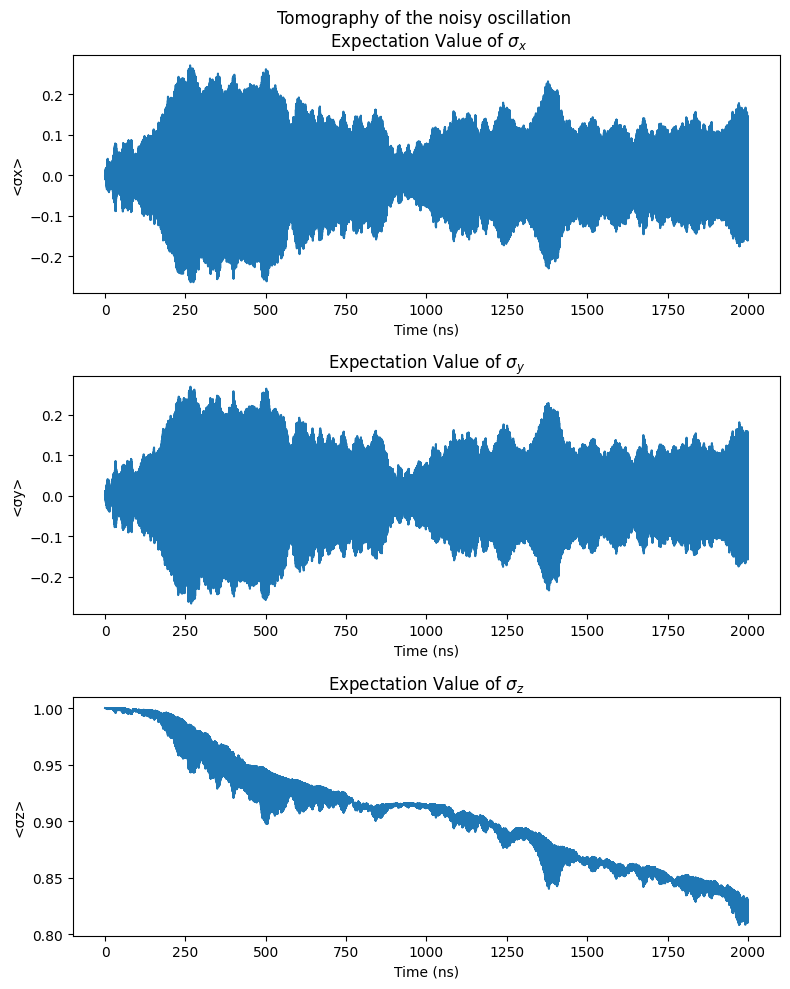

In [90]:
plot_tomography(t, res)

/usr/local/lib/python3.11/dist-packages/matplotlib/cbook.py:1709: ComplexWarning: Casting complex values to real discards the imaginary part
  return math.isfinite(val)
/usr/local/lib/python3.11/dist-packages/matplotlib/cbook.py:1345: ComplexWarning: Casting complex values to real discards the imaginary part
  return np.asarray(x, float)


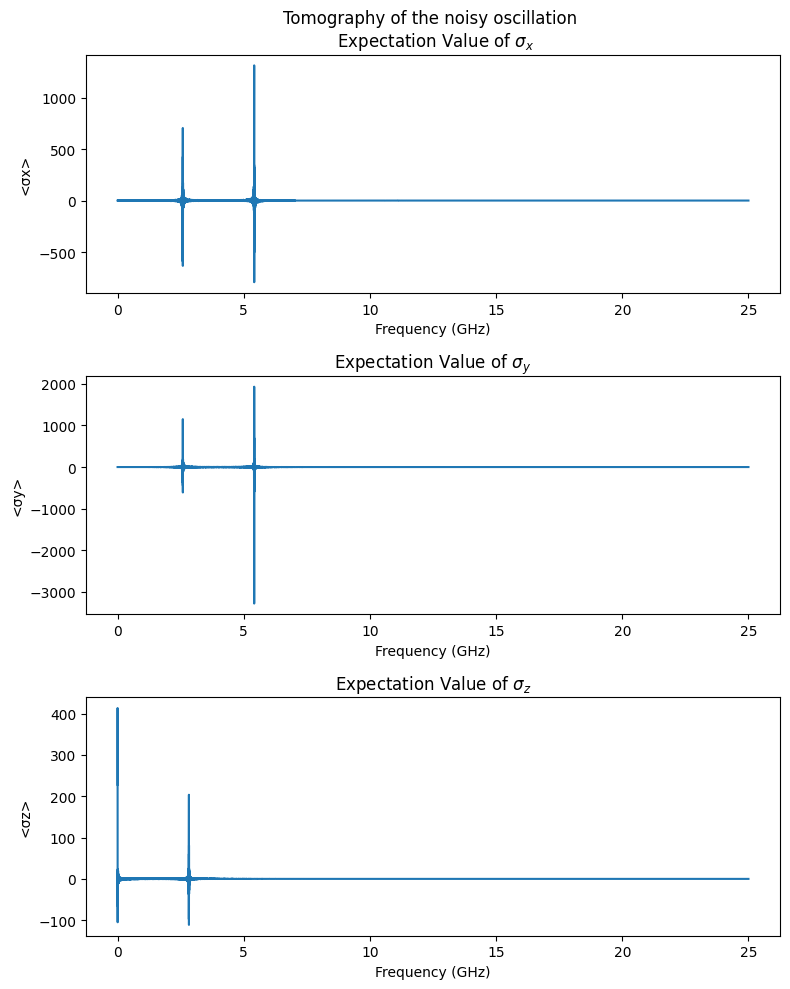

DC amplitude: (90634.39773954413+0j)


In [91]:
plot_fft_tomography(t, res)

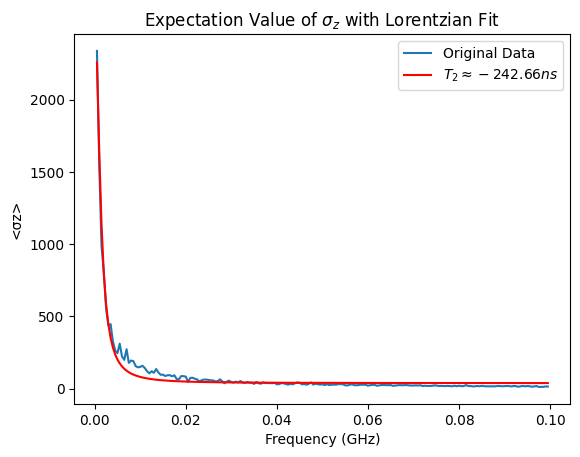

Fitted Offset: 37.32
Fitted Amplitude (S0): 2542.53
Fitted T2 -242.66 ns
std of increments (volatility): 4.196393252743024e-06


In [92]:
lorenztian_fit(t, res.expect[2], T2_0)

Fitted Offset: 1.18
Fitted Amplitude (S0): 113.14
Fitted T2 99.20 ns
Fitted f0 2.83 GHz


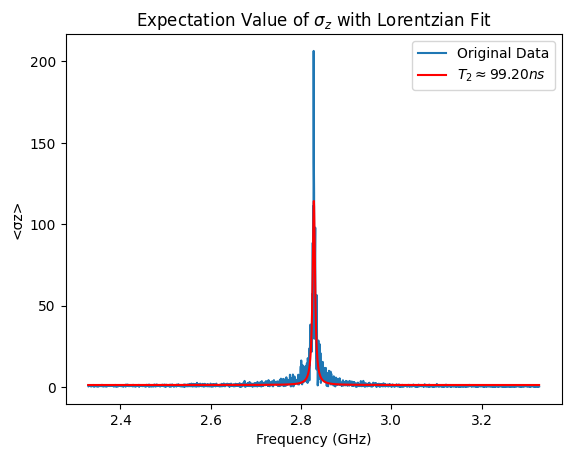

In [93]:
lorenztian_fit2(t, res.expect[2], T2_1, peak)

In [107]:
# parameters

g=2*2*np.pi #coupling between qubit and tls [GHz.rad]
#Qubit
wq0=3*2*np.pi #qubit resonance frequency [GHz.rad]
T1_0=10000 #relaxation time [ns]
T2_0=150 #dephasing time [ns]
Ed0=0.64*2*np.pi #driving energy [GHz.rad]

#TLS
wq1=5*2*np.pi #tls resonance frequency [GHz.rad]
T1_1=10000 #relaxation time [ns]
T2_1=1000 #dephasing time [ns]
Ed1=0.128*2*np.pi #driving energy [GHz.rad]

peak=np.sqrt((wq1-wq0)**2+4*g**2)/2/np.pi
print(peak)
t, res = simulation( g, wq0, T1_0, T2_0, wq1, T1_1, T2_1, Ed1, Ed0=Ed0)

4.47213595499958


/usr/local/lib/python3.11/dist-packages/matplotlib/cbook.py:1709: ComplexWarning: Casting complex values to real discards the imaginary part
  return math.isfinite(val)
/usr/local/lib/python3.11/dist-packages/matplotlib/cbook.py:1345: ComplexWarning: Casting complex values to real discards the imaginary part
  return np.asarray(x, float)


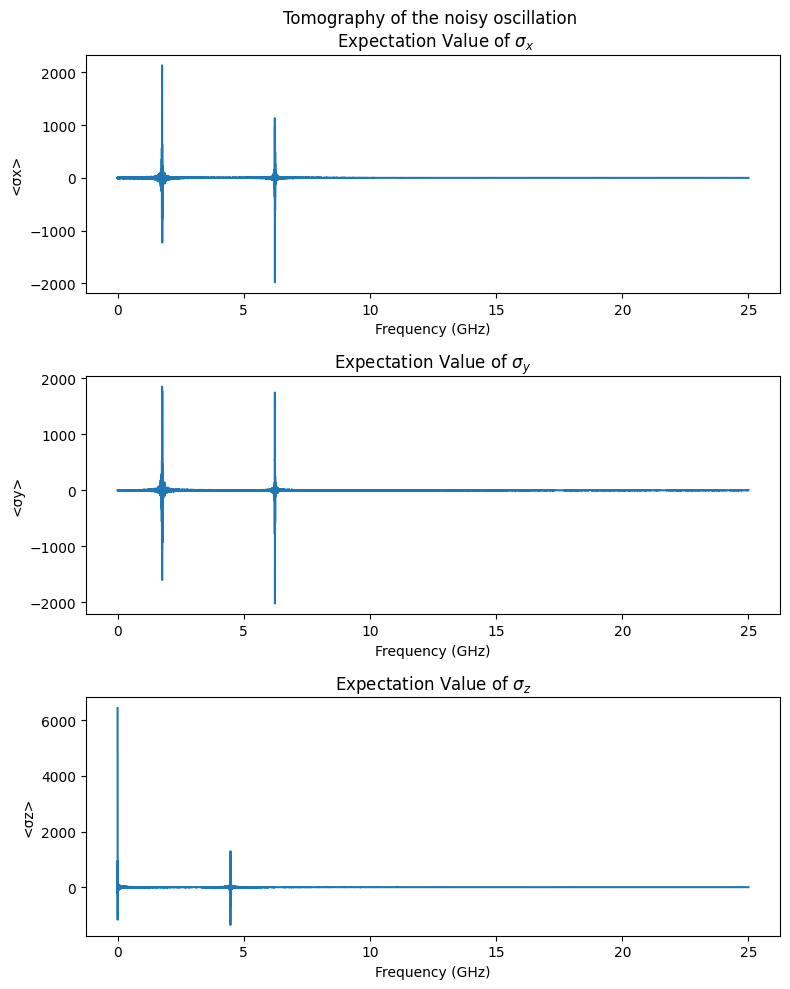

DC amplitude: (19002.152150369708+0j)


In [108]:
plot_fft_tomography(t, res)

Fitted Offset: 9.97
Fitted Amplitude (S0): 1452.25
Fitted T2 88.15 ns
Fitted f0 4.47 GHz


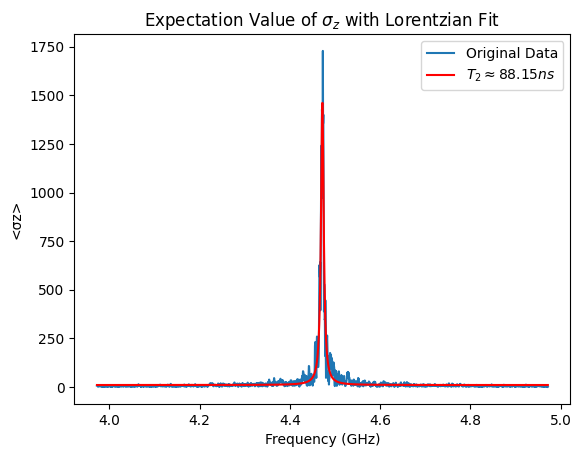

In [117]:
lorenztian_fit2(t, res.expect[2], T2_1, peak=peak)

In [ ]:
ĺ